# Segmentación interactiva con GrabCut

Este cuaderno presenta el algoritmo **GrabCut** para la segmentación interactiva de lesiones en imágenes de resonancia magnética cerebral.

El método se estudiará en dos etapas:

1. **Implementación didáctica:** se desarrollarán paso a paso los principales componentes matemáticos de GrabCut: modelo de mezclas gaussianas, costos de apariencia, coherencia espacial, construcción del grafo y corte mínimo.
2. **Implementación con OpenCV:** se utilizará `cv2.grabCut` para observar cómo estos pasos son encapsulados por una implementación optimizada.

Finalmente, ambas segmentaciones se compararán con una máscara de referencia mediante el **error cuadrático medio (ECM)**.

In [26]:
%matplotlib widget

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Imagen de trabajo

Sea $x_i$ la intensidad del píxel $i$ de una imagen en escala de grises.

Para desarrollar el algoritmo se utilizará un único caso como ejemplo. Cada caso del conjunto de datos está identificado mediante la convención `VS-SEG-XXX`.

La imagen original se encuentra en:

```text
data/images/
```

Durante las siguientes secciones, esta imagen permitirá construir paso a paso los modelos probabilísticos y espaciales utilizados por GrabCut.

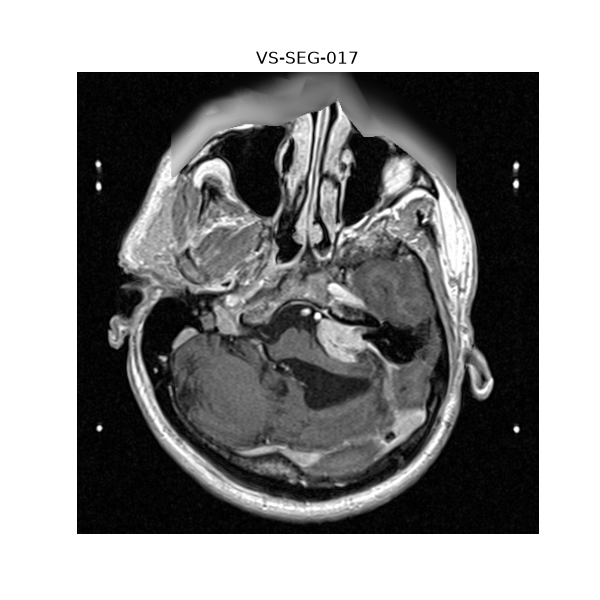

In [27]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

case_id = "VS-SEG-017"
image_path = DATA_DIR / "images" / f"{case_id}.png"

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(case_id)
plt.axis("off")
plt.show()

## 3. Selección interactiva de la ROI

GrabCut utiliza una **región de interés (ROI)** para inicializar la segmentación.

La ROI se representa mediante el rectángulo

$$
R=(x,y,w,h),
$$

donde $(x,y)$ corresponde a la esquina superior izquierda, mientras que $w$ y $h$ representan su ancho y altura.

El usuario selecciona una región que contiene la lesión y parte del tejido circundante. Los píxeles exteriores se utilizarán inicialmente como **fondo seguro**, mientras que los píxeles interiores constituirán la región candidata para la segmentación.

El rectángulo rojo puede reajustarse interactivamente y no representa el contorno final de la lesión; únicamente proporciona la inicialización espacial del algoritmo.

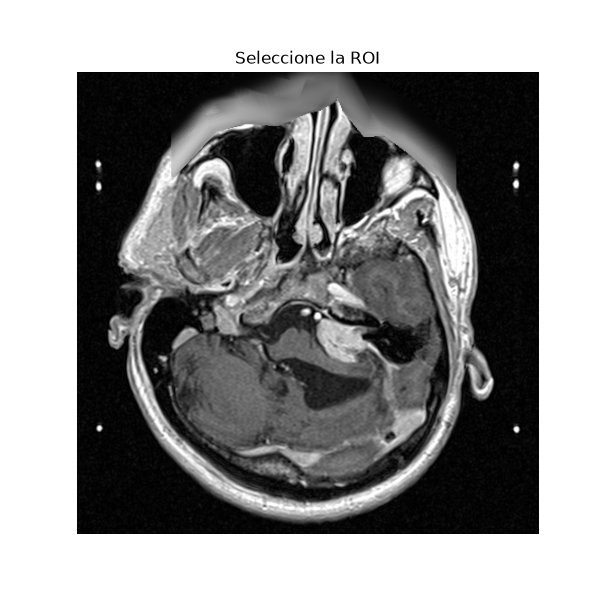

In [28]:
from IPython.display import display
from matplotlib.widgets import RectangleSelector

roi_state = {}


def on_select(eclick, erelease):
    x1, y1 = eclick.xdata, eclick.ydata
    x2, y2 = erelease.xdata, erelease.ydata

    roi_state["value"] = (
        int(min(x1, x2)),
        int(min(y1, y2)),
        int(abs(x2 - x1)),
        int(abs(y2 - y1)),
    )

    ax.set_title(f"ROI = {roi_state['value']}")
    fig.canvas.draw_idle()


with plt.ioff():
    fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(image, cmap="gray")
ax.set_title("Seleccione la ROI")
ax.axis("off")

selector = RectangleSelector(
    ax,
    on_select,
    button=[1],
    interactive=True,
    useblit=False,
    props={
        "edgecolor": "red",
        "facecolor": "red",
        "alpha": 0.2,
        "fill": True,
    },
)

display(fig.canvas)

## 4. Inicialización de etiquetas

A cada píxel $i$ se le asigna una etiqueta provisional

$$
\alpha_i \in \{0,1\},
$$

donde

$$
\alpha_i =
\begin{cases}
0, & \text{si el píxel pertenece al fondo},\\
1, & \text{si el píxel pertenece a la región candidata}.
\end{cases}
$$

La ROI seleccionada en la sección anterior proporciona la inicialización:

- los píxeles **fuera** del rectángulo se consideran fondo seguro;
- los píxeles **dentro** del rectángulo se consideran provisionalmente parte de la región candidata.

Esta clasificación todavía no constituye la segmentación final. Su propósito es proporcionar muestras iniciales para estimar los modelos de apariencia de fondo y primer plano.

In [30]:
x, y, w, h = roi_state["value"]

labels = np.zeros_like(image, dtype=np.uint8)
labels[y:y + h, x:x + w] = 1

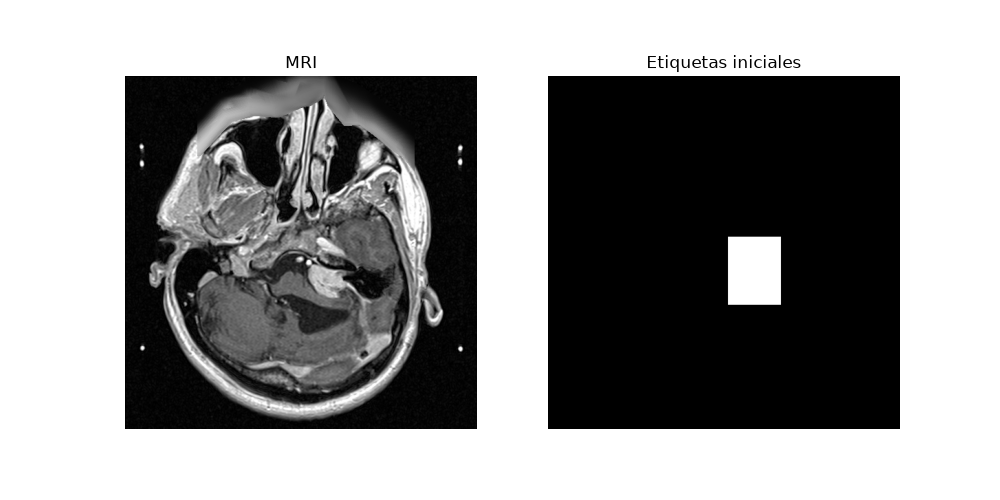

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("MRI")

axes[1].imshow(labels, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Etiquetas iniciales")

for ax in axes:
    ax.axis("off")

plt.show()